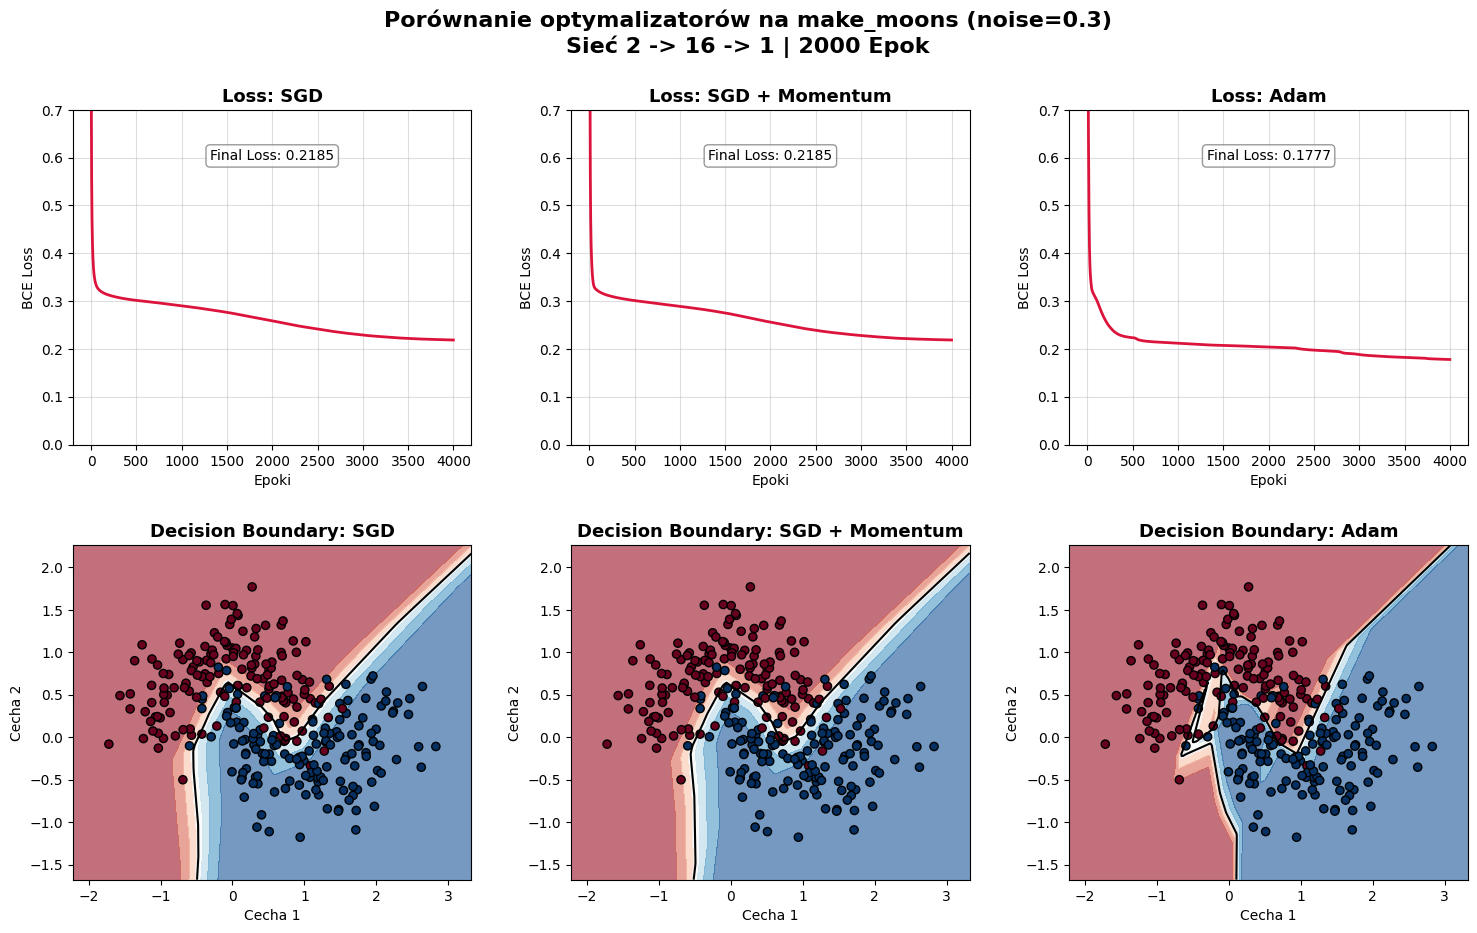

In [4]:
# Porownaj SGD, SGD+Momentum, Adam na make_moons(noise=0.3).
# Wymagania:
# Implementacja od zera (klasy SGD, SGDMomentum, Adam)
# Siec: 2 --> 16 --> 1
# Trening 2000 epok
# Narysuj loss_curves i granice decyzyjne dla kazdego (subplots 2x3)
# Porownaj szybkosc konwergencji
# Oczekiwany wynik:
# 6 wykresow (3 loss + 3 granice)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import copy

class SGD:
    """Vanilla Stochastic Gradient Descent.
    w = w - lr * gradient"""
    def __init__(self, lr=0.01):
        self.lr = lr
    def update(self, params, grads):
        for p, g in zip(params, grads):
            p -= self.lr * g

class SGDMomentum:
    """SGD z Momentum -- dodaje bezwladnosc.
    v = beta * v + (1-beta) * gradient
    w = w - lr * v"""
    def __init__(self, lr=0.01, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.velocities = None
    def update(self, params, grads):
        if self.velocities is None:
            self.velocities = [np.zeros_like(p) for p in params]
        for i, (p, g) in enumerate(zip(params, grads)):
            self.velocities[i] = self.beta * self.velocities[i] + (1 - self.beta) * g
            p -= self.lr * self.velocities[i]

class Adam:
    """Adam -- Adaptive Moment Estimation.
    Laczy Momentum + RMSprop z korekcja biasu.
    DOMYSLNY optymalizator w Deep Learning."""
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None # first moment (mean of gradients)
        self.v = None # second moment (mean of squared gradients)
        self.t = 0 # timestep
    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]
            self.v = [np.zeros_like(p) for p in params]
        self.t += 1
        for i, (p, g) in enumerate(zip(params, grads)):
            # Aktualizacja momentow
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            # Korekcja biasu (wazna na poczatku treningu)
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            # Aktualizacja wag
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# SIEĆ NEURONOWA OD ZERA (2 --> 16 --> 1)

class NeuralNetwork:
    def __init__(self):
        np.random.seed(42) # Stałe ziarno dla powtarzalności wag startowych
        # Inicjalizacja wag (He Init dla ReLU, Xavier dla Sigmoid)
        self.W1 = np.random.randn(2, 16) * np.sqrt(2.0 / 2)
        self.b1 = np.zeros((1, 16))
        self.W2 = np.random.randn(16, 1) * np.sqrt(2.0 / 16)
        self.b2 = np.zeros((1, 1))
        
    @property
    def params(self):
        return [self.W1, self.b1, self.W2, self.b2]
    
    def relu(self, Z):
        return np.maximum(0, Z)
    
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
    
    def backward(self, X, y):
        m = X.shape[0]
        # Pochodne dla Binary Cross-Entropy + Sigmoid
        dZ2 = self.A2 - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        # Pochodne przez warstwę ukrytą (ReLU)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0) 
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        return [dW1, db1, dW2, db2]

def binary_cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    eps = 1e-15 # Unikanie log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m

# PRZYGOTOWANIE TRENINGU

X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
y = y.reshape(-1, 1)

base_model = NeuralNetwork()

# Słownik zdefiniowany poprawnie jako 'experiments'
experiments = {
    'SGD': (SGD(lr=0.1), copy.deepcopy(base_model)),
    'SGD + Momentum': (SGDMomentum(lr=0.1, beta=0.9), copy.deepcopy(base_model)),
    'Adam': (Adam(lr=0.01), copy.deepcopy(base_model))
}

epochs = 4000
loss_histories = {name: [] for name in experiments.keys()}

# Pętla treningowa
for name, (optimizer, model) in experiments.items():
    for epoch in range(epochs):
        y_pred = model.forward(X)
        loss = binary_cross_entropy(y_pred, y)
        loss_histories[name].append(loss)
        
        grads = model.backward(X, y)
        optimizer.update(model.params, grads)

# GENEROWANIE WYKRESÓW (SUBPLOTS 2x3)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() - 0.5 + 1.0
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() - 0.5 + 1.0
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

for idx, (name, (_, model)) in enumerate(experiments.items()):
    # ---- Rząd 1: Loss Curves ----
    ax_loss = axes[0, idx]
    ax_loss.plot(loss_histories[name], color='crimson', linewidth=2)
    ax_loss.set_title(f"Loss: {name}", fontsize=13, fontweight='bold')
    ax_loss.set_xlabel("Epoki")
    ax_loss.set_ylabel("BCE Loss")
    ax_loss.grid(True, alpha=0.4)
    ax_loss.set_ylim(0, 0.7)
    ax_loss.text(0.5, 0.85, f"Final Loss: {loss_histories[name][-1]:.4f}", 
                 transform=ax_loss.transAxes, ha='center', 
                 bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8))

    # ---- Rząd 2: Granice Decyzyjne ----
    ax_bound = axes[1, idx]
    Z = model.forward(grid_points).reshape(xx.shape)
    
    ax_bound.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6)
    ax_bound.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
    ax_bound.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.RdBu, edgecolors='k', s=35)
    
    ax_bound.set_title(f"Decision Boundary: {name}", fontsize=13, fontweight='bold')
    ax_bound.set_xlabel("Cecha 1")
    ax_bound.set_ylabel("Cecha 2")

plt.suptitle("Porównanie optymalizatorów na make_moons (noise=0.3)\nSieć 2 -> 16 -> 1 | 2000 Epok", fontsize=16, fontweight='bold', y=0.98)
plt.show()

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Wczytywanie danych
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Podział na zbiór treningowy i testowy (stratyfikacja ze względu na balans klas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. DEFINICJA PIPELINE I GRID SEARCH DLA MLP
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    # max_iter=500 zazwyczaj wystarcza do zbieżności na tym zbiorze i skraca czas pracy
    ('mlp', MLPClassifier(max_iter=500, random_state=42))  
])

# Definicja siatki hiperparametrów
param_grid = {
    'mlp__hidden_layer_sizes': [(32,), (64, 32), (128, 64)],
    'mlp__solver': ['adam', 'sgd'],
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__activation': ['relu', 'tanh']
}

# Uruchomienie GridSearchCV z parametrem verbose
print("Rozpoczynam przeszukiwanie siatki hiperparametrów dla MLP (CV=5)...")
print("Cierpliwości, to może chwilę potrwać (120 kombinacji do przetestowania).\n")

grid_search_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Wykorzystanie wszystkich rdzeni procesora
    verbose=3   # Pokazuje postęp prac w konsoli, dzięki czemu wiesz, że kod działa
)

grid_search_mlp.fit(X_train, y_train)

# 3. WYŚWIETLENIE TOP 5 KONFIGURACJI MLP
cv_results = pd.DataFrame(grid_search_mlp.cv_results_)

columns_to_show = [
    'param_mlp__activation', 
    'param_mlp__hidden_layer_sizes', 
    'param_mlp__solver', 
    'param_mlp__learning_rate_init', 
    'mean_test_score', 
    'std_test_score'
]
top_5_mlp = cv_results[columns_to_show].sort_values(by='mean_test_score', ascending=False).head(5)

print("\n" + "="*20 + " TOP 5 KONFIGURACJI MLP (CV Score) " + "="*20)
for rank, (idx, row) in enumerate(top_5_mlp.iterrows(), 1):
    print(f"Rank {rank}: Acc = {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f}) | "
          f"Act: {row['param_mlp__activation']}, Layers: {row['param_mlp__hidden_layer_sizes']}, "
          f"Solver: {row['param_mlp__solver']}, LR: {row['param_mlp__learning_rate_init']}")

# Wyciągamy najlepszy model
best_mlp_model = grid_search_mlp.best_estimator_

# 4. PORÓWNANIE NAJLEPSZEGO MLP Z RANDOM FOREST
print("\n" + "="*20 + " TRENOWANIE RANDOM FOREST " + "="*20)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predykcje na zbiorze testowym
y_pred_mlp = best_mlp_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nWyniki końcowe na zbiorze testowym (Holdout):")
print(f"-> Najlepsze MLP Test Accuracy:  {acc_mlp:.4f}")
print(f"-> Random Forest Test Accuracy: {acc_rf:.4f}")

print("\nRaport klasyfikacji dla Najlepszego MLP:")
print(classification_report(y_test, y_pred_mlp, target_names=cancer.target_names))

print("Raport klasyfikacji dla Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=cancer.target_names))




Rozpoczynam przeszukiwanie siatki hiperparametrów dla MLP (CV=5)...
Cierpliwości, to może chwilę potrwać (120 kombinacji do przetestowania).

Fitting 5 folds for each of 24 candidates, totalling 120 fits

==================== TOP 5 KONFIGURACJI MLP (CV Score) ====================
Rank 1: Acc = 0.9824 (±0.0112) | Act: tanh, Layers: (64, 32), Solver: sgd, LR: 0.001
Rank 2: Acc = 0.9824 (±0.0132) | Act: tanh, Layers: (32,), Solver: sgd, LR: 0.01
Rank 3: Acc = 0.9824 (±0.0132) | Act: tanh, Layers: (32,), Solver: adam, LR: 0.01
Rank 4: Acc = 0.9802 (±0.0128) | Act: tanh, Layers: (32,), Solver: adam, LR: 0.001
Rank 5: Acc = 0.9802 (±0.0162) | Act: relu, Layers: (32,), Solver: sgd, LR: 0.01

==================== TRENOWANIE RANDOM FOREST ====================

Wyniki końcowe na zbiorze testowym (Holdout):
-> Najlepsze MLP Test Accuracy:  0.9561
-> Random Forest Test Accuracy: 0.9561

Raport klasyfikacji dla Najlepszego MLP:
              precision    recall  f1-score   support

   malignant    